In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Elogroup/CNH data literacy/Beg/M7/US_Lightning_Forest_Fires.csv")
df.head()

,Unnamed: 0,index,FIRE_YEAR,Fire_Date,DISCOVERY_TIME,STAT_CAUSE_DESCR,Days_to_extinguish_fire,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,STATE,FIPS_CODE,FIPS_NAME
0,0,1,2004,05-12-2004,845.0,Lightning,0.0,1530.0,0.25,A,38.933056,-120.404444,CA,61.0,Placer
1,1,3,2004,06-28-2004,1600.0,Lightning,5.0,1400.0,0.10,A,38.559167,-119.913333,CA,3.0,Alpine
2,2,4,2004,06-28-2004,1600.0,Lightning,5.0,1200.0,0.10,A,38.559167,-119.933056,CA,3.0,Alpine
3,3,5,2004,06-30-2004,1800.0,Lightning,1.0,1600.0,0.10,A,38.635278,-120.103611,CA,5.0,Amador
4,4,6,2004,07-01-2004,1800.0,Lightning,1.0,1400.0,0.10,A,38.688333,-120.153333,CA,17.0,El Dorado


In [4]:
df = df.rename(columns={
    "Unnamed: 0": "unnamed",
    "FIRE_YEAR": "fire_year",
    "Fire_Date": "fire_date",
    "DISCOVERY_TIME": "discovery_time",
    "STAT_CAUSE_DESCR": "fire_cause",
    "Days_to_extinguish_fire": "days_to_extinguish",
    "CONT_TIME": "control_time",
    "FIRE_SIZE": "fire_size",
    "FIRE_SIZE_CLASS": "fire_size_class",
    "LATITUDE": "latitude",
    "LONGITUDE": "longitude",
    "STATE": "state",
    "FIPS_CODE": "fips_code",
    "FIPS_NAME": "fips_name"
})

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278468 entries, 0 to 278467
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   unnamed             278468 non-null  int64  
 1   index               278468 non-null  int64  
 2   fire_year           278468 non-null  int64  
 3   fire_date           278468 non-null  object 
 4   discovery_time      228272 non-null  float64
 5   fire_cause          278468 non-null  object 
 6   days_to_extinguish  227876 non-null  float64
 7   control_time        220068 non-null  float64
 8   fire_size           278468 non-null  float64
 9   fire_size_class     278468 non-null  object 
 10  latitude            278468 non-null  float64
 11  longitude           278468 non-null  float64
 12  state               278468 non-null  object 
 13  fips_code           156911 non-null  float64
 14  fips_name           156911 non-null  object 
dtypes: float64(7), int64(3), object(5)

## Data Sanity

In [10]:
cols = [
    "fire_year",
    "fire_date",
    "discovery_time",
    "days_to_extinguish",
    "control_time",
    "fire_size",
    "fire_size_class",
    "latitude",
    "longitude",
    "state"
]

df = df[cols]

df = df.drop_duplicates()

df["fire_date"] = pd.to_datetime(df["fire_date"], errors="coerce")

df.dropna(inplace=True, axis=1)

df = df[df["fire_size"] > 0]
df = df[df["days_to_extinguish"] >= 0]

df["fire_year"] = df["fire_year"].astype(int)

df["year_group"] = pd.cut(
    df["fire_year"],
    bins=[1990, 2000, 2010, 2020, 2030],
    labels=["1990s", "2000s", "2010s", "2020s"]
)

top_states = df["state"].value_counts().head(8).index
df_top = df[df["state"].isin(top_states)]

In [12]:
df.columns

Index(['fire_year', 'fire_date', 'discovery_time', 'days_to_extinguish',
       'fire_size', 'fire_size_class', 'latitude', 'longitude', 'state',
       'year_group'],
      dtype='object')

## EDA - Exploratory Data Analysis

Line plot

Question: How did the average days to extinguish fires change over the years?

Use: Use a line plot to show trends over time.

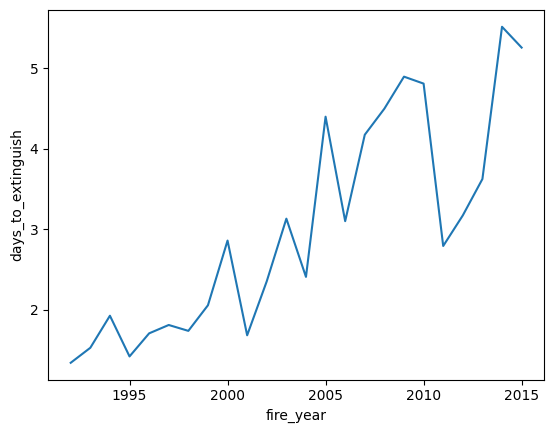

In [14]:
yearly = df.groupby("fire_year", as_index=False)["days_to_extinguish"].mean()

sns.lineplot(data=yearly, x="fire_year", y="days_to_extinguish")
plt.show()

In [15]:
import plotly.express as px

px.line(yearly, x="fire_year", y="days_to_extinguish").show()

Fill between

Question: During the year, when do fire counts usually increase?

Use: Use fill between to show variation around a trend, especially when comparing the usual range across months.

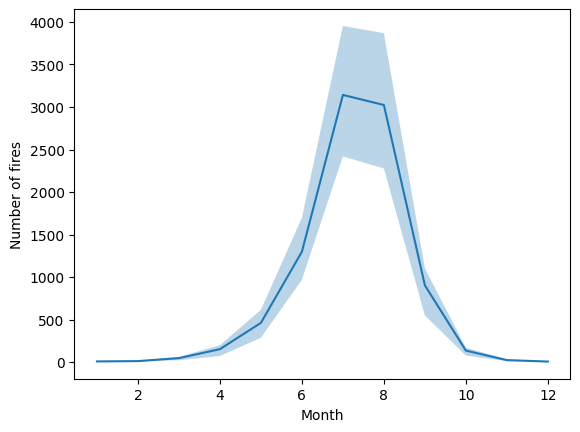

In [21]:
df["month"] = df["fire_date"].dt.month

monthly_year = (
    df.groupby(["fire_year", "month"])
    .size()
    .reset_index(name="fire_count")
)

monthly_range = (
    monthly_year.groupby("month")["fire_count"]
    .agg(
        mean="mean",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

plt.plot(monthly_range["month"], monthly_range["mean"])
plt.fill_between(
    monthly_range["month"],
    monthly_range["q25"],
    monthly_range["q75"],
    alpha=0.3
)

plt.xlabel("Month")
plt.ylabel("Number of fires")
plt.show()

In [31]:
monthly_year[monthly_year["month"] == 1].mean()

,0
fire_year,2003.956522
month,1.000000
fire_count,8.000000


Bar plot

Question: Which states had the longest average time to extinguish fires?

Use: Use bar plots to compare values across categories.

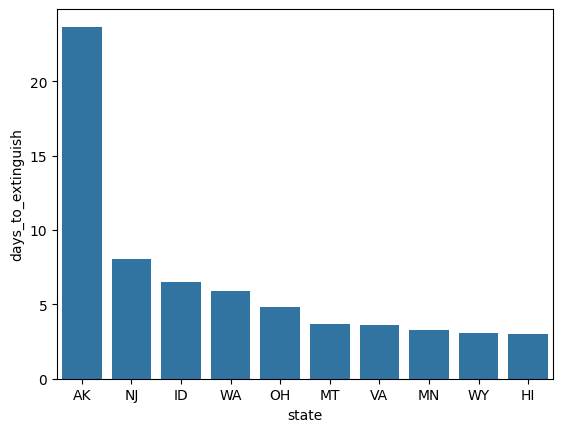

In [34]:
avg_days = df.groupby("state", as_index=False)["days_to_extinguish"].mean()
avg_days = avg_days.sort_values("days_to_extinguish", ascending=False).head(10)

sns.barplot(data=avg_days, x="state", y="days_to_extinguish")
plt.show()

In [35]:
px.bar(avg_days, x="state", y="days_to_extinguish").show()

Bar plot variation

Question:
Do larger fire size classes take longer to extinguish in different states?

Use:
Use bar plots to compare a numeric value across categories.
Use hue when we want to compare subgroups inside each category.

In [89]:
bar_data = (
    df_top[df_top["days_to_extinguish"] <= 50]
    .groupby(["state", "fire_size_class"], as_index=False)["days_to_extinguish"]
    .median()
)

px.bar(
    bar_data,
    x="state",
    y="days_to_extinguish",
    color="fire_size_class",
    barmode="group"
).show()

Countplot

Question: How many fires happened in each state by fire size class?

Use: Use countplots to count records by category, with hue for comparison.

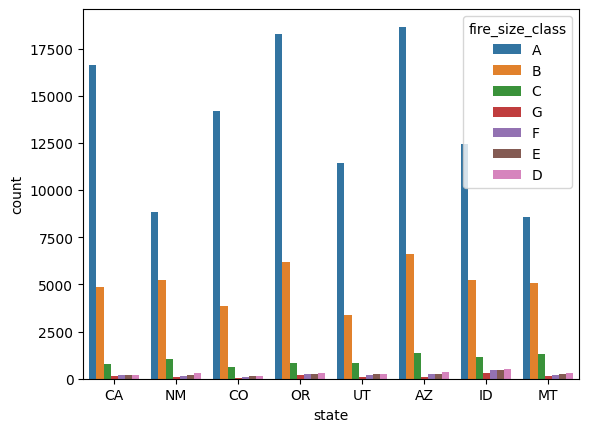

In [36]:
sns.countplot(data=df_top, x="state", hue="fire_size_class")
plt.show()

Histogram

Question: What is the distribution of discovery times?

Use: Use histograms to see how one numeric variable is distributed.

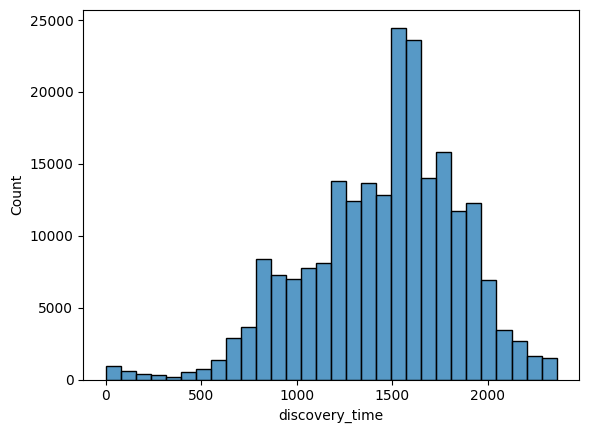

In [37]:
sns.histplot(data=df, x="discovery_time", bins=30)
plt.show()

In [39]:
px.histogram(df, x="discovery_time", nbins=30).show()

KDE

Question: Does discovery time distribution change by state?

Use: Use KDE plots to compare smooth distributions between groups.

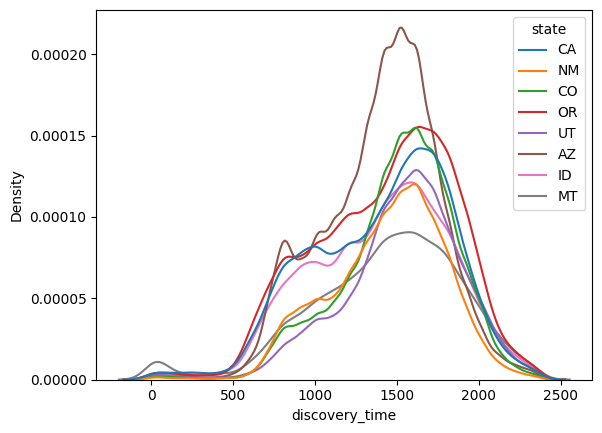

In [40]:
sns.kdeplot(data=df_top, x="discovery_time", hue="state")
plt.show()

Boxplot

Question: How does fire size vary by fire size class?

Use: Use boxplots to compare median, spread and outliers.

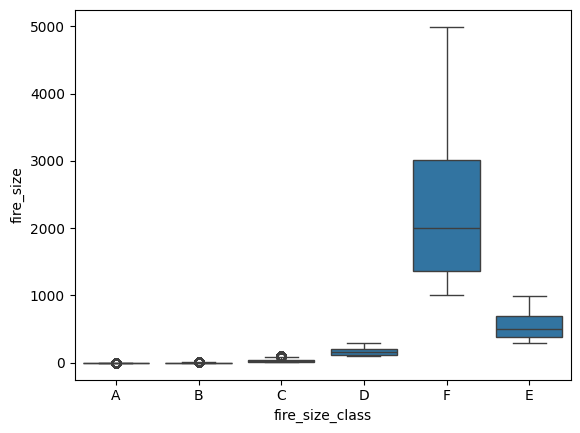

In [48]:
sns.boxplot(data=df[df["fire_size_class"] != "G"], x="fire_size_class", y="fire_size")
plt.show()

Fire size usually has a very skewed distribution: most fires are small, but a few fires are extremely large.

If we use the original scale, the very large fires stretch the y-axis and make it difficult to see the differences between most observations.

Using a log scale compresses very large values and makes the boxplot easier to interpret. This helps us compare the median, spread and outliers across fire size classes without letting a few extreme values dominate the chart.

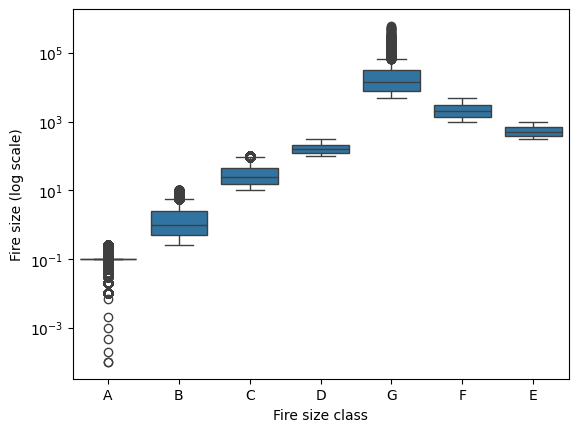

In [50]:
sns.boxplot(
    data=df,
    x="fire_size_class",
    y="fire_size"
)

plt.yscale("log")
plt.xlabel("Fire size class")
plt.ylabel("Fire size (log scale)")
plt.show()

We could also make a cap on some values, to better show the important information.

In [51]:
px.box(df, x="fire_size_class", y="fire_size", log_y=True).show()

Box plot

Question: How do discovery time varies?

Use: Use boxplots to compare distribution

Alternative: Violin Plot or swarm plot

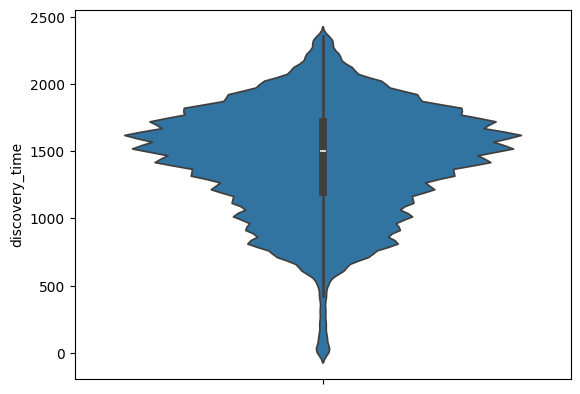

In [83]:
sns.violinplot(data=df_top, y="discovery_time")
plt.show()

Scatter plot

Question: Do larger fires take more days to extinguish?

Use: Use scatter plots to analyze the relationship between two numeric variables.

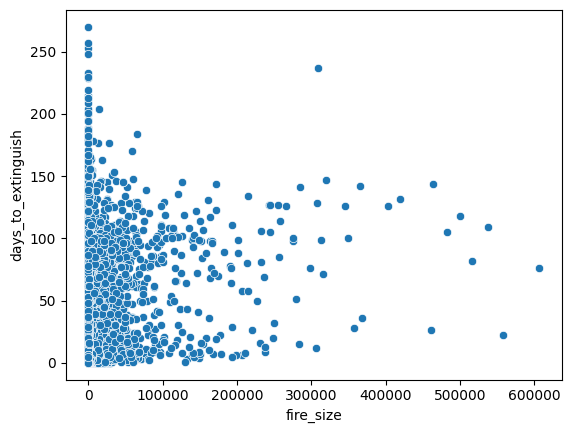

In [66]:
sns.scatterplot(data=df, x="fire_size", y="days_to_extinguish")
plt.show()

In [67]:

px.scatter(df, x="fire_size", y="days_to_extinguish").show()

Heatmap

Question: Which numeric variables are most correlated?

Use: Use heatmaps to visualize correlation patterns.

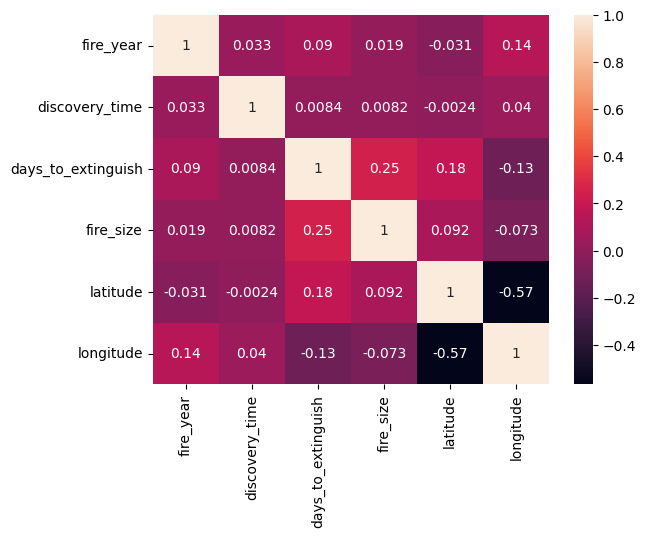

In [73]:
corr = df[[
    "fire_year", "discovery_time",
    "days_to_extinguish", "fire_size", "latitude", "longitude"
]].corr()

sns.heatmap(corr, annot=True)
plt.show()

In [74]:
px.imshow(corr, text_auto=True).show()

Map and bubble plot

Question:
Where are the fires located?

Use:
Use maps to see geographic patterns.

In [87]:
import folium

df_map = (
    df.groupby("state", as_index=False)
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        fire_count=("state", "count")
    )
)

m = folium.Map(
    location=[df_map["latitude"].mean(), df_map["longitude"].mean()],
    zoom_start=4
)

for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["fire_count"] / df_map["fire_count"].max() * 25,
        tooltip=f"{row['state']}: {row['fire_count']} fires",
        fill=True
    ).add_to(m)

m

Plotly Express is simpler and faster for common charts.

Plotly Graph Objects gives more control over the chart structure. Instead of creating the whole plot automatically, we manually define:

- the figure
- the trace, such as a bar chart
- the layout, such as titles and dropdown menus
- the interactive buttons

This is useful when we want the user to interact with the chart, for example choosing which variable to visualize from a dropdown.


In [91]:
import plotly.graph_objects as go

plot_data = (
    df
    .groupby("fire_size_class", as_index=False)
    .agg(
        avg_fire_size=("fire_size", "mean"),
        median_fire_size=("fire_size", "median"),
        avg_days_to_extinguish=("days_to_extinguish", "mean"),
        avg_discovery_time=("discovery_time", "mean"),
        fire_count=("fire_size_class", "count")
    )
)

variables = {
    "Average fire size": "avg_fire_size",
    "Median fire size": "median_fire_size",
    "Average days to extinguish": "avg_days_to_extinguish",
    "Average discovery time": "avg_discovery_time",
    "Number of fires": "fire_count"
}

first_label = list(variables.keys())[0]
first_col = variables[first_label]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=plot_data["fire_size_class"],
        y=plot_data[first_col]
    )
)

buttons = []

for label, col in variables.items():
    buttons.append(
        dict(
            label=label,
            method="update",
            args=[
                {"y": [plot_data[col]]},
                {
                    "title": f"{label} by fire size class",
                    "yaxis": {"title": label}
                }
            ]
        )
    )

fig.update_layout(
    title=f"{first_label} by fire size class",
    xaxis_title="Fire size class",
    yaxis_title=first_label,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=1.15,
            y=1
        )
    ]
)

fig.show()

# Lie with plots and Statistics (and how to avoid being fooled by it)

Example 1 — Cut the y-axis

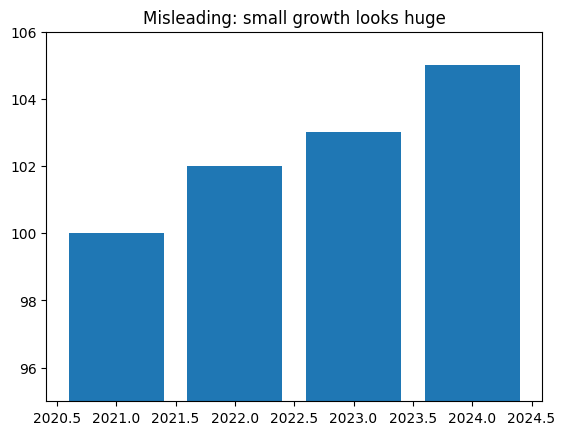

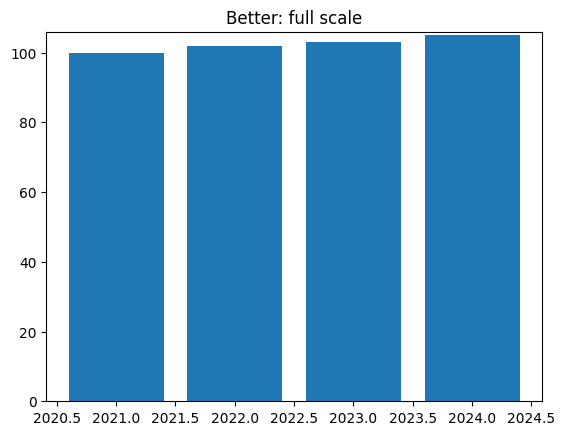

In [92]:
import matplotlib.pyplot as plt

years = [2021, 2022, 2023, 2024]
sales = [100, 102, 103, 105]

plt.bar(years, sales)
plt.ylim(95, 106)
plt.title("Misleading: small growth looks huge")
plt.show()

plt.bar(years, sales)
plt.ylim(0, 106)
plt.title("Better: full scale")
plt.show()

Example 2 — Cherry-pick dates

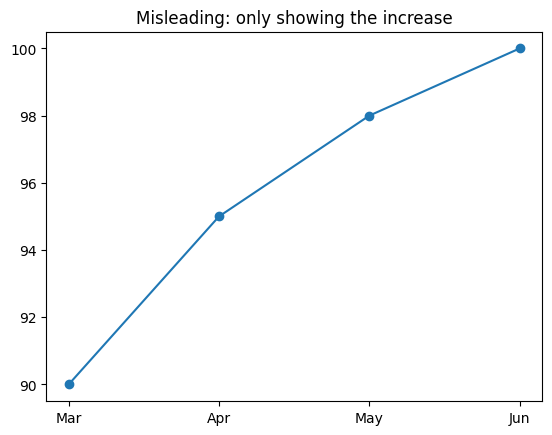

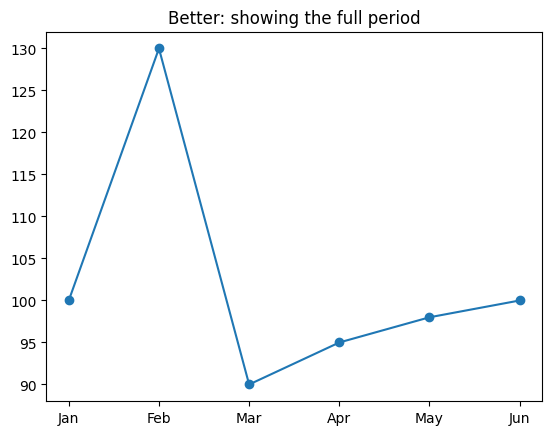

In [94]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
values = [100, 130, 90, 95, 98, 100]

plt.plot(months[2:], values[2:], marker="o")
plt.title("Misleading: only showing the increase")
plt.show()

plt.plot(months, values, marker="o")
plt.title("Better: showing the full period")
plt.show()

Example 3 — Bad histogram bins

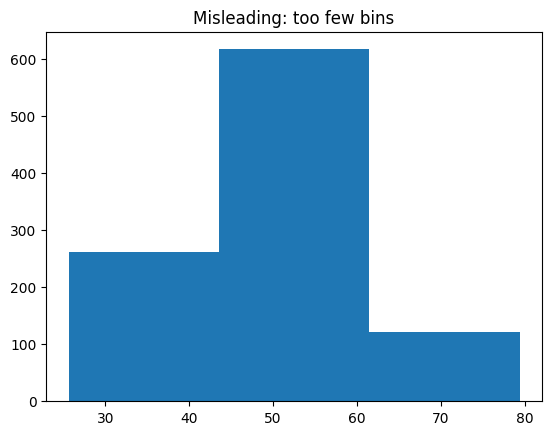

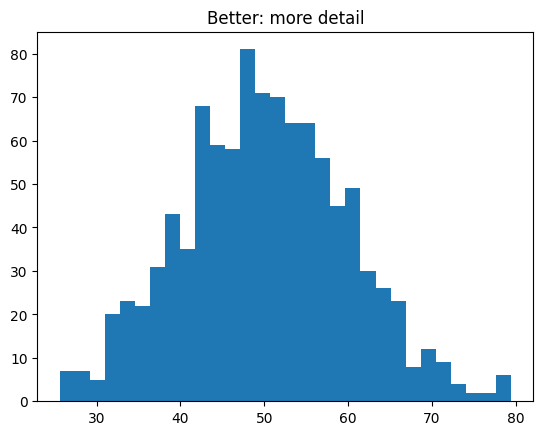

In [95]:
import numpy as np

data = np.random.normal(50, 10, 1000)

plt.hist(data, bins=3)
plt.title("Misleading: too few bins")
plt.show()

plt.hist(data, bins=30)
plt.title("Better: more detail")
plt.show()

Example 4 — Mean hides the distribution

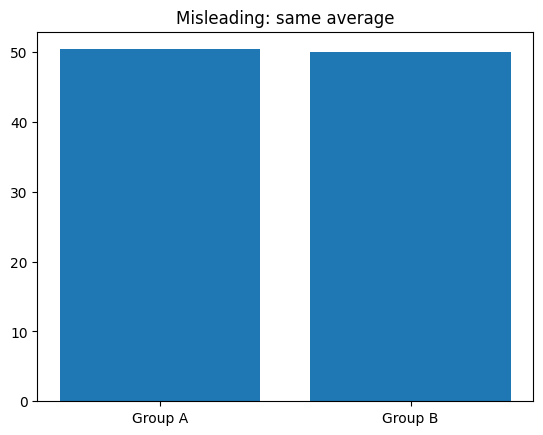

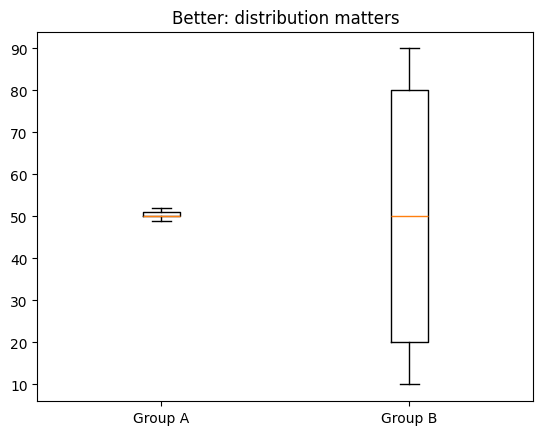

In [97]:
group_a = [50, 51, 49, 50, 52]
group_b = [10, 20, 50, 80, 90]

plt.bar(["Group A", "Group B"], [np.mean(group_a), np.mean(group_b)])
plt.title("Misleading: same average")
plt.show()

plt.boxplot([group_a, group_b], tick_labels=["Group A", "Group B"])
plt.title("Better: distribution matters")
plt.show()